## 1. Import knižníc

# Trénovanie CNN pre predikciu slnečného žiarenia

Tento notebook trénuje konvolučné neurónové siete na predikciu slnečného žiarenia z RGB obrázkov pomocou Intel Arc GPU akcelerácie.

In [24]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torch

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from models.cnn import create_cnn_model
from models.dataset import create_data_loaders
from models.utils import get_device, count_parameters
from models.training import (
    train_model,
    evaluate_model,
    create_optimizer_and_criterion,
    load_checkpoint,
)
from utils.evaluation import (
    plot_training_history,
    plot_residuals,
    plot_predictions_comparison,
)
print(f"Verzia PyTorch: {torch.__version__}")

try:
    import intel_extension_for_pytorch as ipex
    print(f"Intel Extension for PyTorch: {ipex.__version__}")
except (ImportError, OSError) as e:
    print(f"Intel Extension for PyTorch nie je dostupné: {e}")

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    print(f"Intel XPU dostupné: {torch.xpu.device_count()} zariadení")
    for i in range(torch.xpu.device_count()):
        print(f"  [{i}]: {torch.xpu.get_device_name(i)}")
else:
    print("Používa sa CPU (GPU nebolo detekované)")


device = get_device()


Verzia PyTorch: 2.7.0+xpu
Intel Extension for PyTorch: 2.7.10+xpu
Intel XPU dostupné: 1 zariadení
  [0]: Intel(R) Arc(TM) B580 Graphics
Intel Arc GPU detected: Intel(R) Arc(TM) B580 Graphics


## 2. Načítanie spracovaných dát

In [25]:
data_dir = project_root / "dataset" / "Solar_data"
processed_dir = project_root / "dataset" / "processed"

train_df = pl.read_csv(processed_dir / "train.csv")
val_df = pl.read_csv(processed_dir / "val.csv")
test_df = pl.read_csv(processed_dir / "test.csv")

print(f"Trénovacie vzorky: {len(train_df)}")
print(f"Validačné vzorky: {len(val_df)}")
print(f"Testovacie vzorky: {len(test_df)}")

if "ResizedImagePath" in train_df.columns:
    print("\nPoužívame pred-resizované obrázky (rýchlejšie načítavanie)")
else:
    print("\nResizované obrázky nenájdené - spustite najprv 01_exploratory_data_analysis.ipynb")


Trénovacie vzorky: 4204
Validačné vzorky: 901
Testovacie vzorky: 902

Používame pred-resizované obrázky (rýchlejšie načítavanie)


## 3. Definícia hyperparametrických konfigurácií


In [26]:
configs = [
    {
        "name": "Konfigurácia 1: Základná",
        "conv_channels": [16, 32, 64],
        "fc_hidden": [32, 16],
        "dropout": 0.65,
        "learning_rate": 0.001,
        "weight_decay": 0.03,
        "batch_size": 128,
        "epochs": 8,
    },
    {
        "name": "Konfigurácia 2: Hlbšia sieť",
        "conv_channels": [16, 32, 64, 128],
        "fc_hidden": [64, 32],
        "dropout": 0.65,
        "learning_rate": 0.001,
        "weight_decay": 0.03,
        "batch_size": 128,
        "epochs": 8,
    },
    {
        "name": "Konfigurácia 3: Vyšší dropout",
        "conv_channels": [16, 32, 64],
        "fc_hidden": [32, 16],
        "dropout": 0.7,
        "learning_rate": 0.001,
        "weight_decay": 0.03,
        "batch_size": 128,
        "epochs": 8,
    },
    {
        "name": "Konfigurácia 4: Väčší weight decay",
        "conv_channels": [16, 32, 64],
        "fc_hidden": [32, 16],
        "dropout": 0.65,
        "learning_rate": 0.001,
        "weight_decay": 0.1,
        "batch_size": 128,
        "epochs": 8,
    },
    {
        "name": "Konfigurácia 5: Širšia sieť",
        "conv_channels": [24, 48, 96],
        "fc_hidden": [48, 24],
        "dropout": 0.65,
        "learning_rate": 0.0005,
        "weight_decay": 0.04,
        "batch_size": 128,
        "epochs": 8,
    },
]

print(f"Celkový počet konfigurácií: {len(configs)}")
print("\nPravidlo: Conv kanály > FC neuróny, Dropout len na FC")

Celkový počet konfigurácií: 5

Pravidlo: Conv kanály > FC neuróny, Dropout len na FC


## 4. Trénovanie všetkých konfigurácií

In [27]:
results = []
checkpoint_dir = project_root / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

for idx, config in enumerate(configs, 1):
    print(f"\n{'='*80}")
    print(f"Trénovanie {config['name']} ({idx}/{len(configs)})")
    print(f"{'='*80}")
    print(f"Parametre: {config}")
    
    train_loader, val_loader, test_loader = create_data_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        data_dir=data_dir,
        batch_size=config['batch_size'],
        num_workers=0,
    )
    
    model = create_cnn_model(
        conv_channels=config['conv_channels'],
        fc_hidden=config['fc_hidden'],
        dropout_rate=config['dropout'],
        device=device,
    )
    
    print(f"\nPočet parametrov modelu: {count_parameters(model):,}")
    
    optimizer, criterion = create_optimizer_and_criterion(
        model,
        learning_rate=config['learning_rate'],
        weight_decay=config.get('weight_decay', 0.01),
        optimizer_type="adamw",
    )
    
    config_checkpoint_dir = checkpoint_dir / f"config_{idx}"
    config_checkpoint_dir.mkdir(exist_ok=True)
    
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=config['epochs'],
        device=device,
        checkpoint_dir=config_checkpoint_dir,
        early_stopping_patience=3,
        verbose=True,
    )
    
    best_model_path = config_checkpoint_dir / "best_model.pth"
    if best_model_path.exists():
        try:
            load_checkpoint(model, optimizer, best_model_path, device)
            print(f"\nNačítaný najlepší model z {best_model_path}")
        except Exception as e:
            print(f"\nChyba pri načítaní checkpointu: {e}")
    else:
        print(f"\nCheckpoint neexistuje: {best_model_path}")
    
    print("\nVyhodnocovanie na trénovacej množine...")
    train_metrics = evaluate_model(model, train_loader, criterion, device)
    
    print("Vyhodnocovanie na testovacej množine...")
    test_metrics = evaluate_model(model, test_loader, criterion, device)
    
    result = {
        "config_name": config['name'],
        "config_idx": idx,
        "config": config,
        "history": history,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "num_parameters": count_parameters(model),
    }
    results.append(result)
    
    print(f"\nFinálne výsledky pre {config['name']}:")
    print(f"  Trénovacia - MSE: {train_metrics['mse']:.4f}, MAE: {train_metrics['mae']:.4f}, "
          f"RMSE: {train_metrics['rmse']:.4f}, R²: {train_metrics['r2']:.4f}")
    print(f"  Testovacia  - MSE: {test_metrics['mse']:.4f}, MAE: {test_metrics['mae']:.4f}, "
          f"RMSE: {test_metrics['rmse']:.4f}, R²: {test_metrics['r2']:.4f}")

print(f"\n{'='*80}")
print("Všetky konfigurácie úspešne natrénované!")
print(f"{'='*80}")



Trénovanie Konfigurácia 1: Základná (1/5)
Parametre: {'name': 'Konfigurácia 1: Základná', 'conv_channels': [16, 32, 64], 'fc_hidden': [32, 16], 'dropout': 0.65, 'learning_rate': 0.001, 'weight_decay': 0.03, 'batch_size': 128, 'epochs': 8}

Počet parametrov modelu: 173,457


Epoch 1: 100%|██████████| 33/33 [00:07<00:00,  4.25it/s, loss=9.35e+4]




Epoch 1/8:
  Train - Loss: 146690.7620, MSE: 146690.7656, MAE: 274.1049, RMSE: 383.0023, R2: -0.8543
  Val   - Loss: 150597.0686, MSE: 150597.0781, MAE: 280.8011, RMSE: 388.0684, R2: -0.8358


Epoch 2: 100%|██████████| 33/33 [00:07<00:00,  4.58it/s, loss=7.5e+4] 




Epoch 2/8:
  Train - Loss: 72232.7991, MSE: 72232.7969, MAE: 177.6873, RMSE: 268.7616, R2: 0.0869
  Val   - Loss: 5687.4799, MSE: 5687.4800, MAE: 50.0051, RMSE: 75.4154, R2: 0.9307


...


Epoch 5/8:
  Train - Loss: 35543.7197, MSE: 35543.7188, MAE: 118.8954, RMSE: 188.5304, R2: 0.5507
  Val   - Loss: 2383.6264, MSE: 2383.6265, MAE: 34.2792, RMSE: 48.8224, R2: 0.9709


Epoch 6: 100%|██████████| 33/33 [00:07<00:00,  4.65it/s, loss=3.76e+4]




Epoch 6/8:
  Train - Loss: 37100.0333, MSE: 37100.0352, MAE: 119.5217, RMSE: 192.6137, R2: 0.5310
  Val   - Loss: 8378.9833, MSE: 8378.9834, MAE: 62.7005, RMSE: 91.5368, R2: 0.8979


Epoch 7: 100%|██████████| 33/33 [00:07<00:00,  4.69it/s, loss=2.35e+4]




Epoch 7/8:
  Train - Loss: 35313.7715, MSE: 35313.7734, MAE: 115.8861, RMSE: 187.9196, R2: 0.5536
  Val   - Loss: 6714.3604, MSE: 6714.3608, MAE: 53.0888, RMSE: 81.9412, R2: 0.9182

Early stopping at epoch 7

Načítaný najlepší model z c:\Users\pmuzslay\suns_z3\checkpoints\config_5\best_model.pth

Vyhodnocovanie na trénovacej množine...

Načítaný najlepší model z c:\Users\pmuzslay\suns_z3\checkpoints\config_5\best_model.pth

Vyhodnocovanie na trénovacej množine...
Vyhodnocovanie na testovacej množine...
Vyhodnocovanie na testovacej množine...

Finálne výsledky pre Konfigurácia 5: Širšia sieť:
  Trénovacia - MSE: 2079.6860, MAE: 30.6577, RMSE: 45.6036, R²: 0.9737
  Testovacia  - MSE: 2063.7649, MAE: 31.3709, RMSE: 45.4287, R²: 0.9744

Všetky konfigurácie úspešne natrénované!

Finálne výsledky pre Konfigurácia 5: Širšia sieť:
  Trénovacia - MSE: 2079.6860, MAE: 30.6577, RMSE: 45.6036, R²: 0.9737
  Testovacia  - MSE: 2063.7649, MAE: 31.3709, RMSE: 45.4287, R²: 0.9744

Všetky konfigurácie 

## 5. Porovnávacia tabuľka výsledkov

In [28]:
table_data = []
for result in results:
    table_data.append(
        {
            "Konfigurácia": result["config_name"],
            "Parametre": f"{result['num_parameters']:,}",
            "Train MSE": f"{result['train_metrics']['mse']:.4f}",
            "Train MAE": f"{result['train_metrics']['mae']:.4f}",
            "Train RMSE": f"{result['train_metrics']['rmse']:.4f}",
            "Train R²": f"{result['train_metrics']['r2']:.4f}",
            "Test MSE": f"{result['test_metrics']['mse']:.4f}",
            "Test MAE": f"{result['test_metrics']['mae']:.4f}",
            "Test RMSE": f"{result['test_metrics']['rmse']:.4f}",
            "Test R²": f"{result['test_metrics']['r2']:.4f}",
        }
    )

results_df = pl.DataFrame(table_data)

print("\nPorovnanie výsledkov:")

print(results_df)

results_df.write_csv(project_root / "results_table.csv")
print(f"\nVýsledky uložené do {project_root / 'results_table.csv'}")



Porovnanie výsledkov:
shape: (5, 10)
┌─────────────┬───────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬─────────┐
│ Konfiguráci ┆ Parametre ┆ Train MSE ┆ Train MAE ┆ … ┆ Test MSE  ┆ Test MAE ┆ Test RMSE ┆ Test R² │
│ a           ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---     │
│ ---         ┆ str       ┆ str       ┆ str       ┆   ┆ str       ┆ str      ┆ str       ┆ str     │
│ str         ┆           ┆           ┆           ┆   ┆           ┆          ┆           ┆         │
╞═════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═════════╡
│ Konfiguráci ┆ 173,457   ┆ 5598.3999 ┆ 51.1830   ┆ … ┆ 5850.4893 ┆ 53.0935  ┆ 76.4885   ┆ 0.9275  │
│ a 1:        ┆           ┆           ┆           ┆   ┆           ┆          ┆           ┆         │
│ Základná    ┆           ┆           ┆           ┆   ┆           ┆          ┆           ┆         │
│ Konfiguráci ┆ 698,065   ┆ 2143.0801 ┆ 30.3041   ┆ …

## 6. Výber najlepšej konfigurácie

In [29]:
best_idx = np.argmax([r['test_metrics']['r2'] for r in results])
best_result = results[best_idx]

print(f"Najlepšia konfigurácia: {best_result['config_name']}")
print(f"Test R²: {best_result['test_metrics']['r2']:.4f}")
print(f"Test RMSE: {best_result['test_metrics']['rmse']:.4f}")
print(f"Test MAE: {best_result['test_metrics']['mae']:.4f}")
print(f"Test MSE: {best_result['test_metrics']['mse']:.4f}")

Najlepšia konfigurácia: Konfigurácia 5: Širšia sieť
Test R²: 0.9744
Test RMSE: 45.4287
Test MAE: 31.3709
Test MSE: 2063.7649


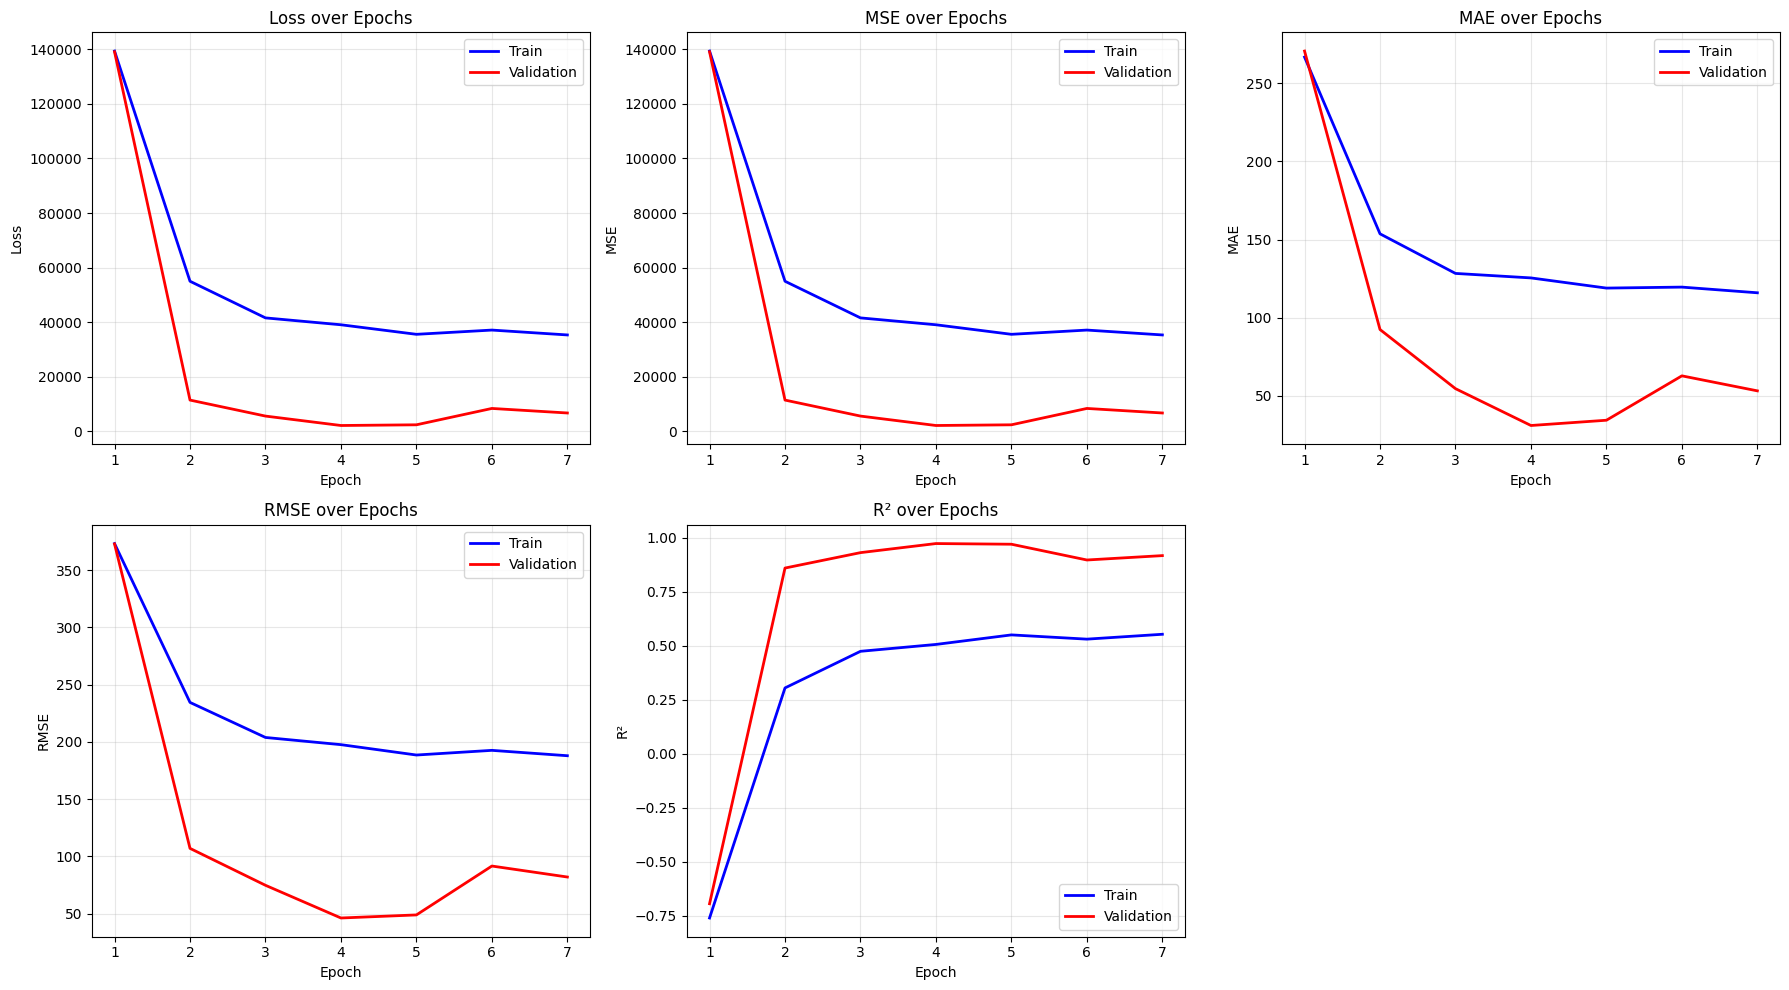

História trénovania uložená do c:\Users\pmuzslay\suns_z3\figures


In [30]:
fig_dir = project_root / "figures"
fig_dir.mkdir(exist_ok=True)

fig = plot_training_history(
    best_result['history'],
    save_path=fig_dir / f"training_history_config_{best_result['config_idx']}.png"
)
plt.show()
print(f"História trénovania uložená do {fig_dir}")

## 8. Analýza reziduí najlepšieho modelu

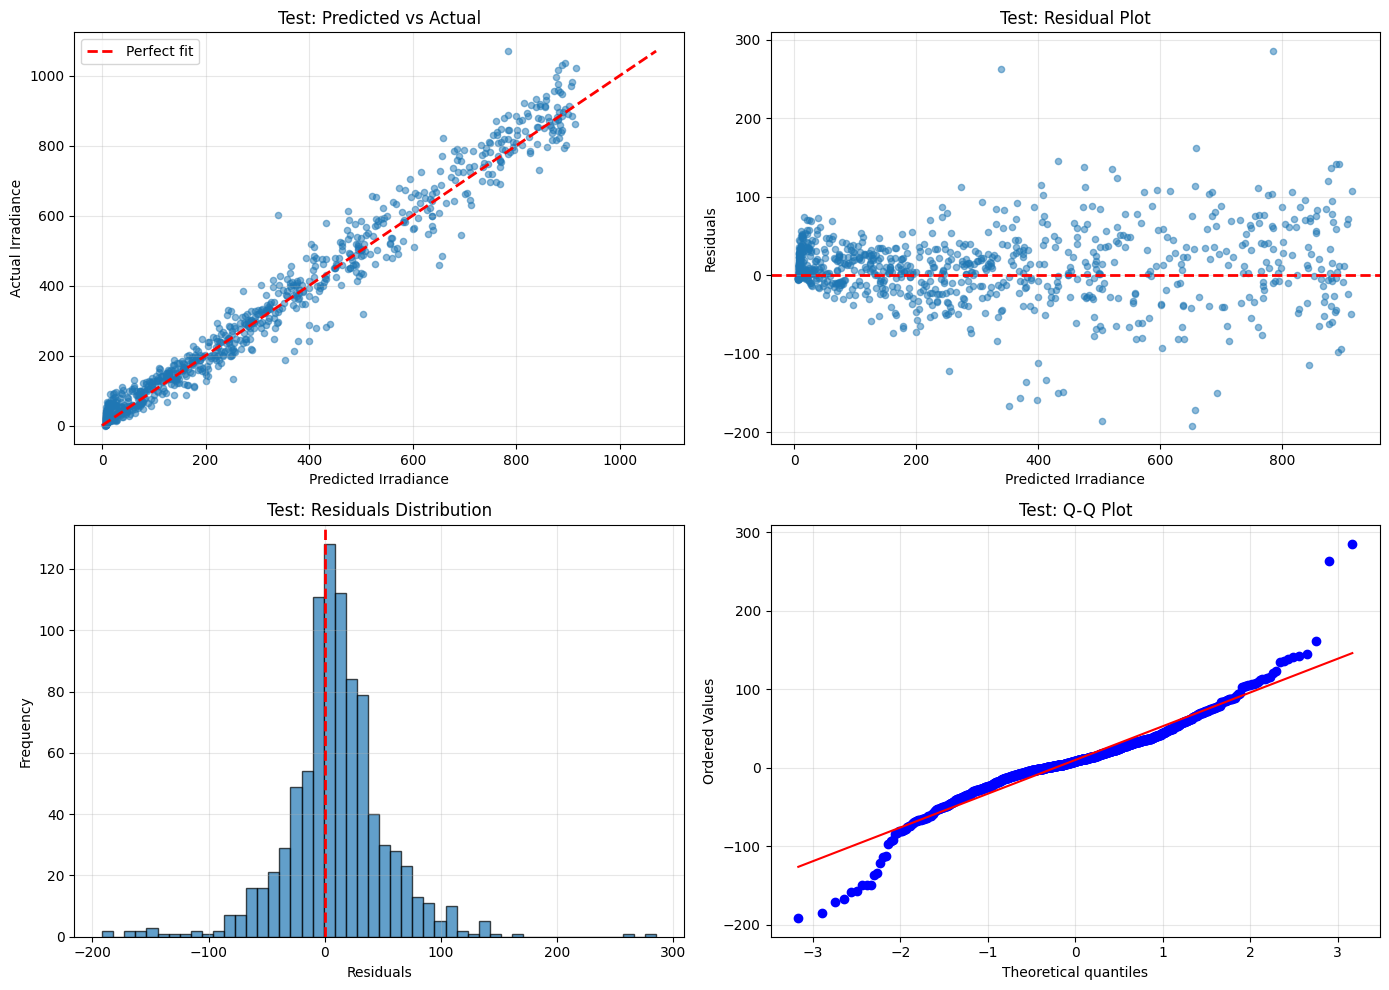

Grafy reziduí uložené do c:\Users\pmuzslay\suns_z3\figures


In [31]:
fig = plot_residuals(
    targets=best_result['test_metrics']['targets'],
    predictions=best_result['test_metrics']['predictions'],
    split_name="Test",
    save_path=fig_dir / f"residuals_config_{best_result['config_idx']}.png"
)
plt.show()
print(f"Grafy reziduí uložené do {fig_dir}")

## 9. Porovnanie predikcií najlepšieho modelu

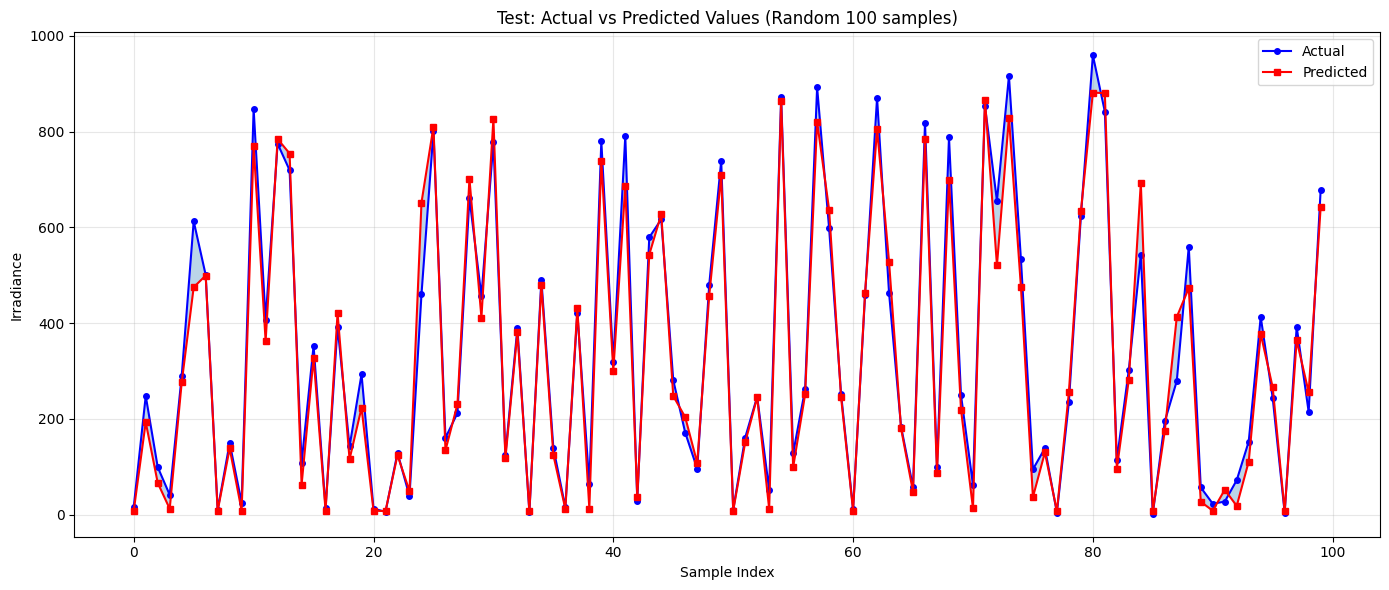

Porovnanie predikcií uložené do c:\Users\pmuzslay\suns_z3\figures


In [32]:
fig = plot_predictions_comparison(
    targets=best_result['test_metrics']['targets'],
    predictions=best_result['test_metrics']['predictions'],
    split_name="Test",
    n_samples=100,
    save_path=fig_dir / f"predictions_comparison_config_{best_result['config_idx']}.png"
)
plt.show()
print(f"Porovnanie predikcií uložené do {fig_dir}")

## 10. História trénovania všetkých konfigurácií


Vykresľovanie histórie trénovania pre Konfigurácia 1: Základná


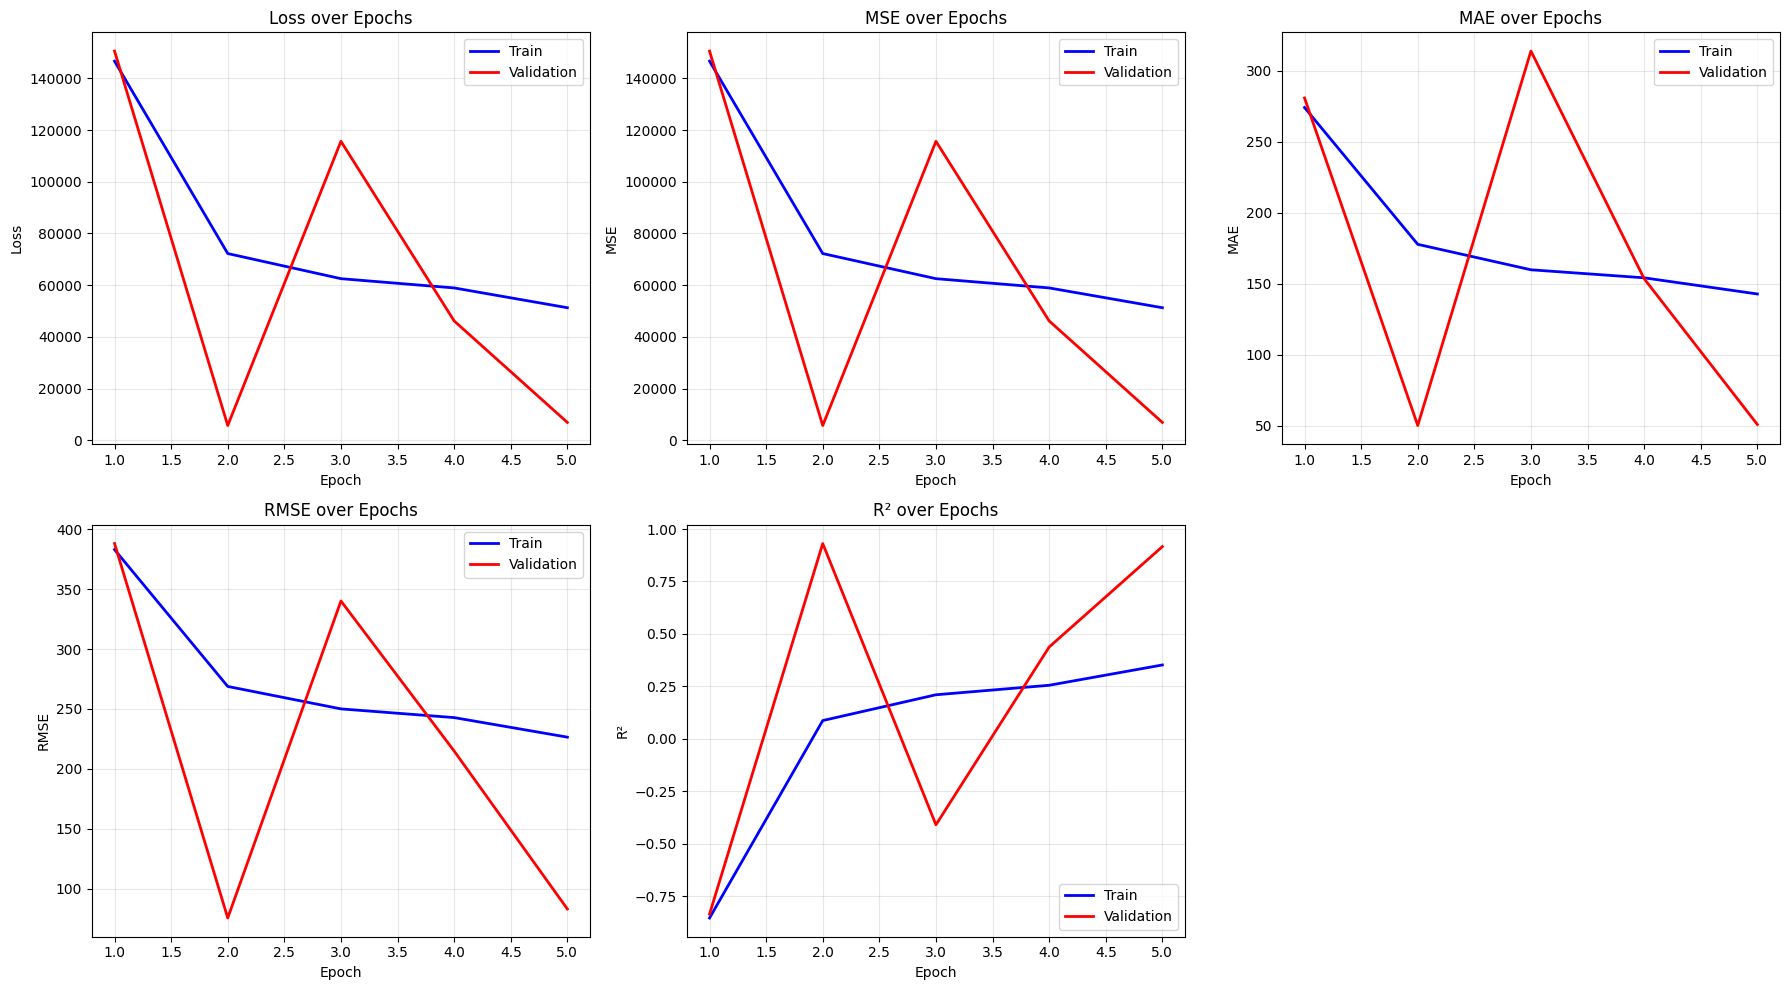


Vykresľovanie histórie trénovania pre Konfigurácia 2: Hlbšia sieť


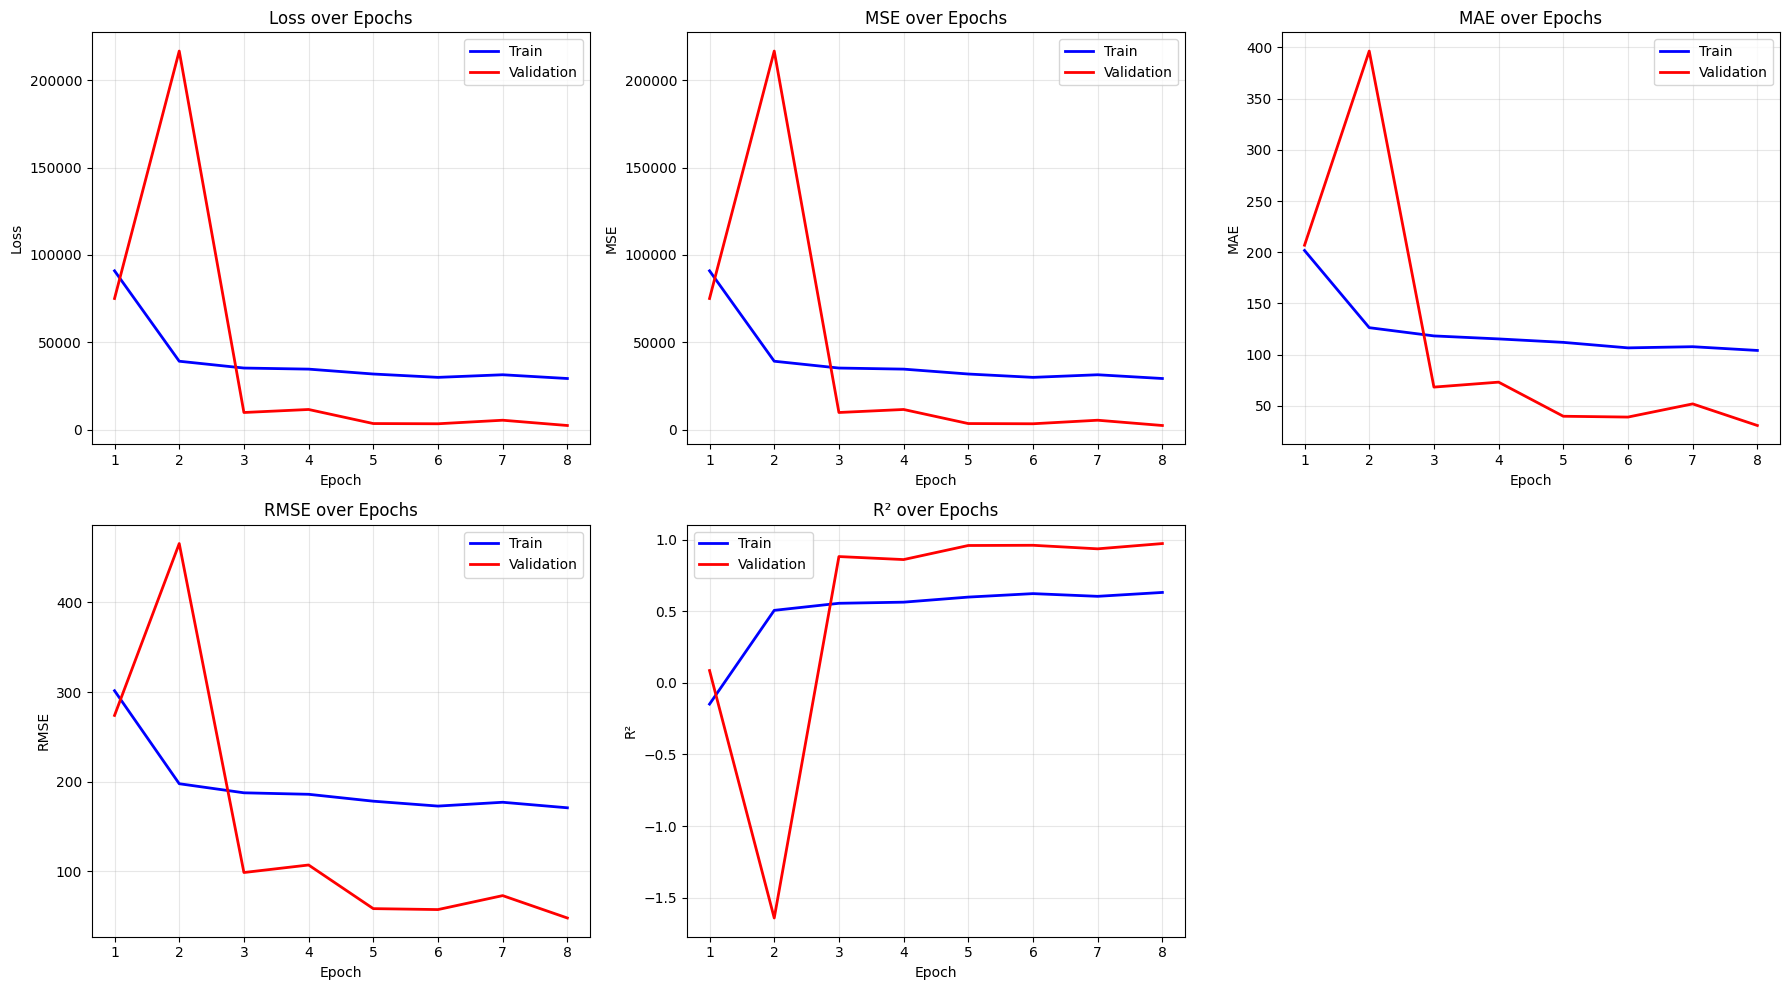


Vykresľovanie histórie trénovania pre Konfigurácia 3: Vyšší dropout


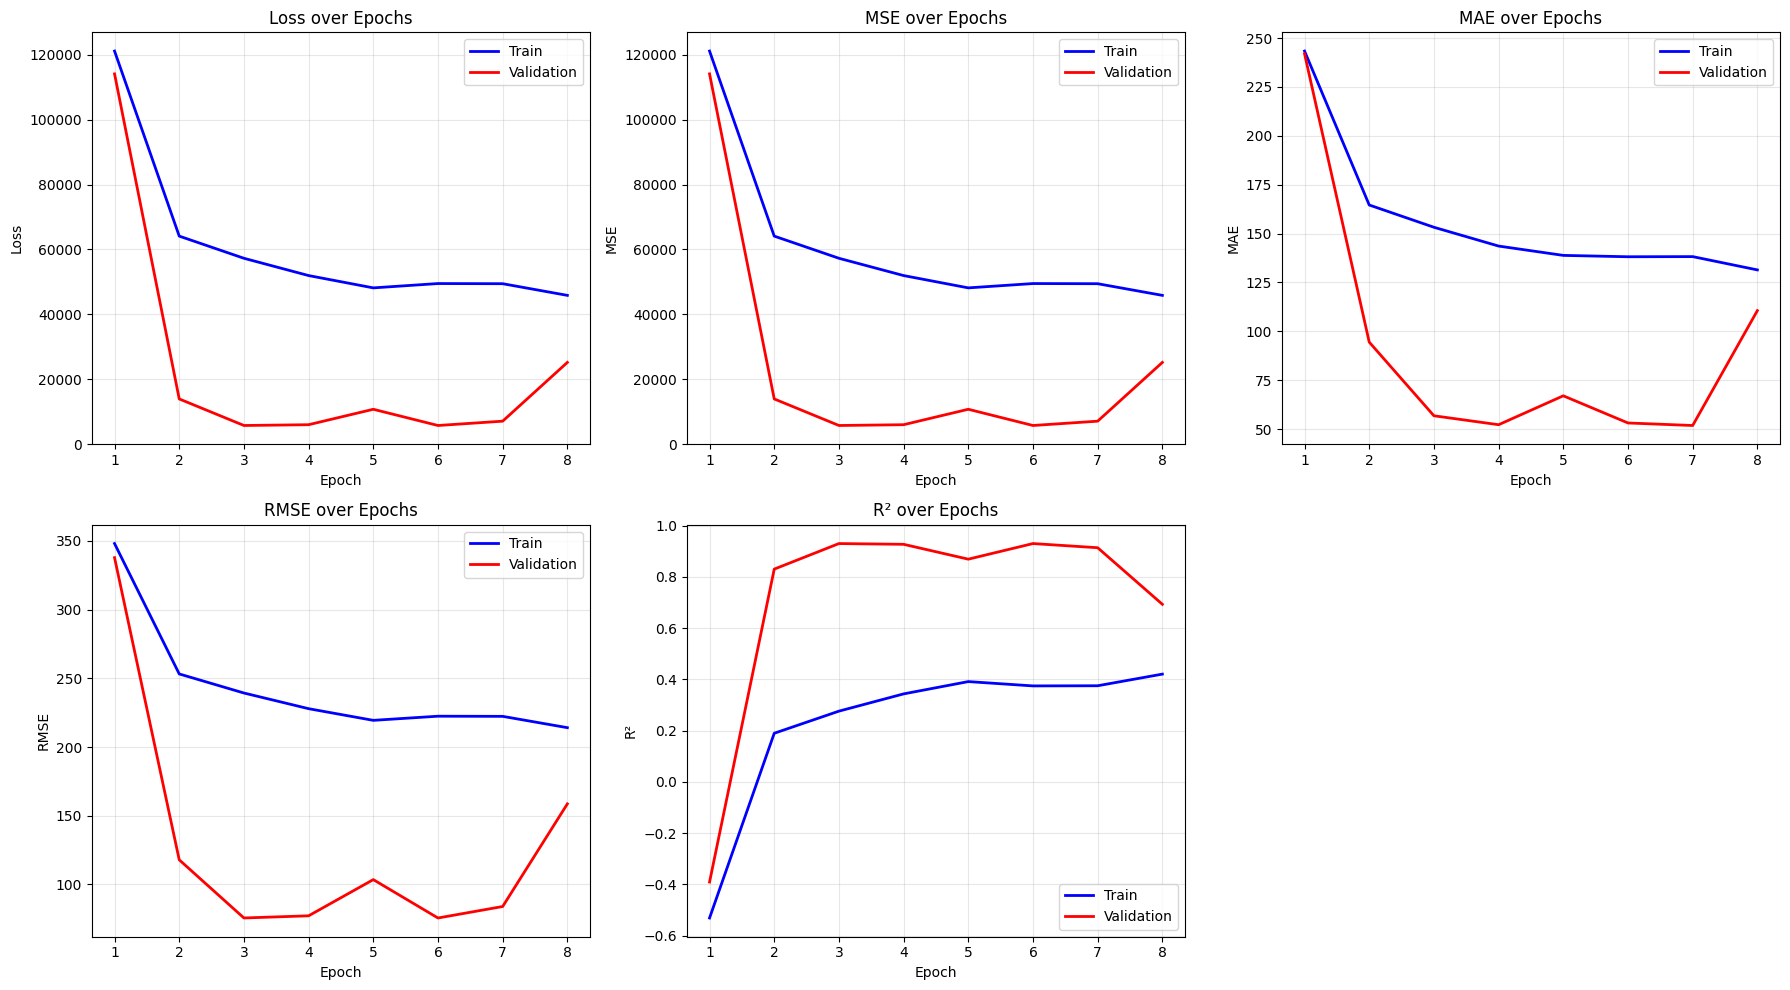


Vykresľovanie histórie trénovania pre Konfigurácia 4: Väčší weight decay


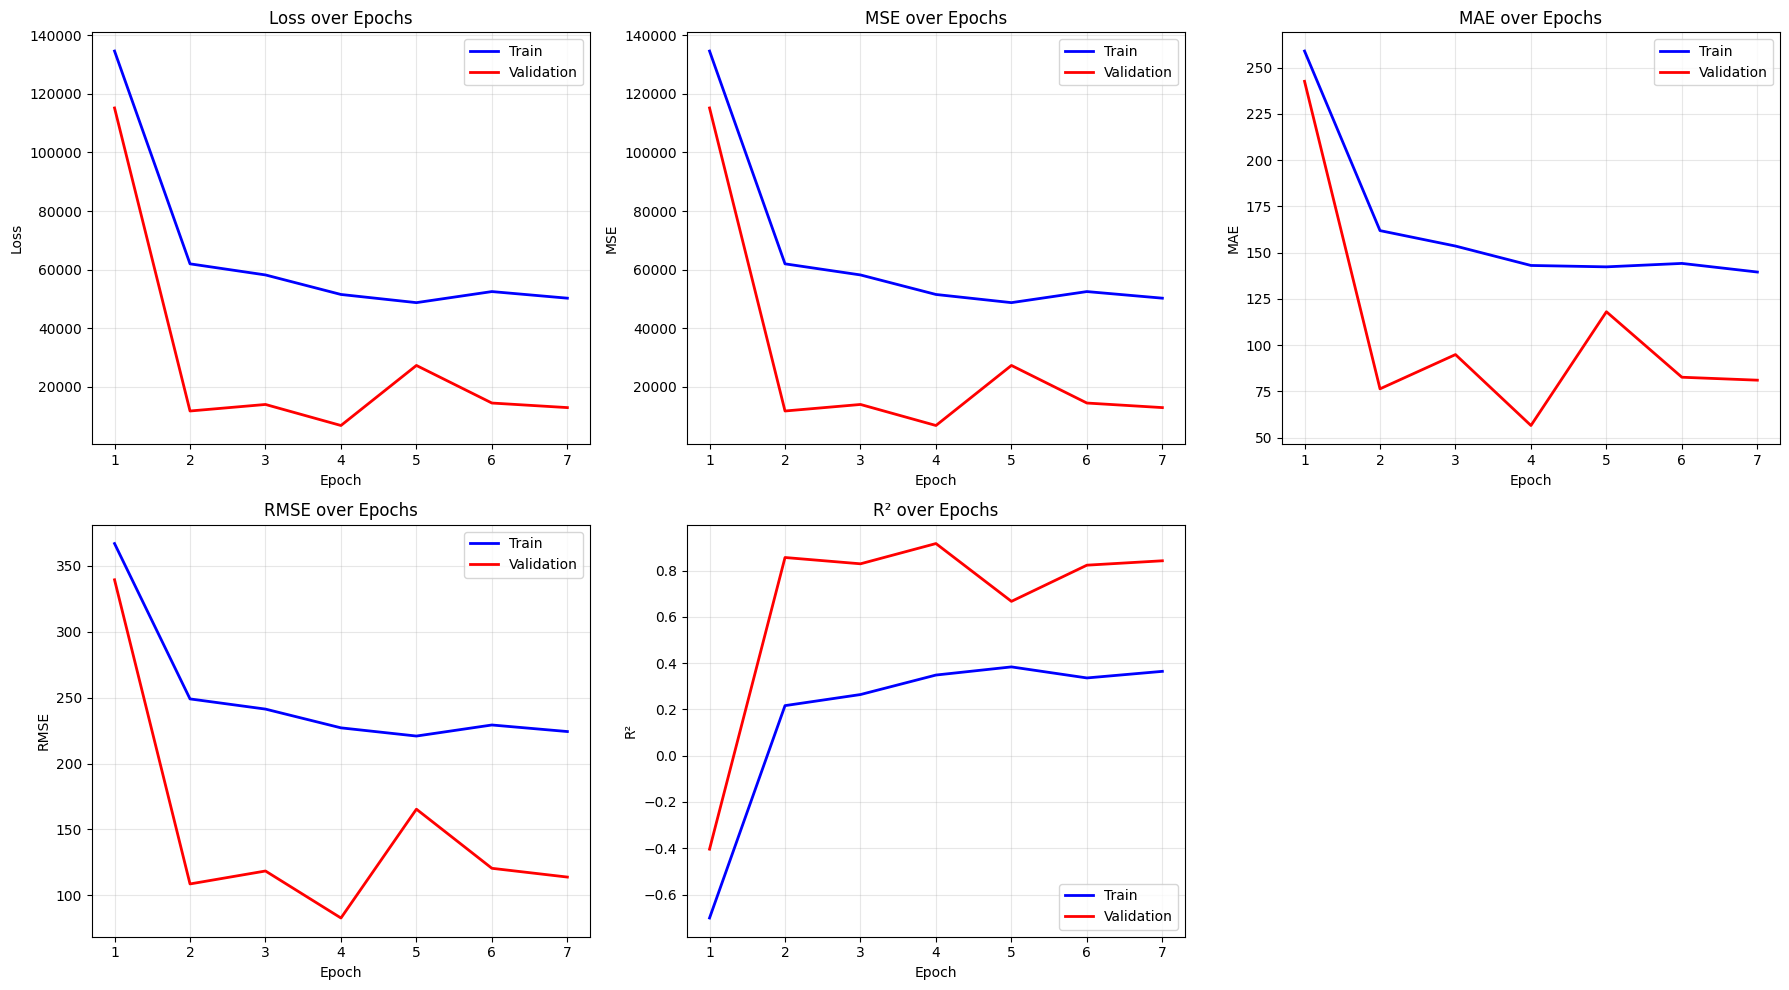


Vykresľovanie histórie trénovania pre Konfigurácia 5: Širšia sieť


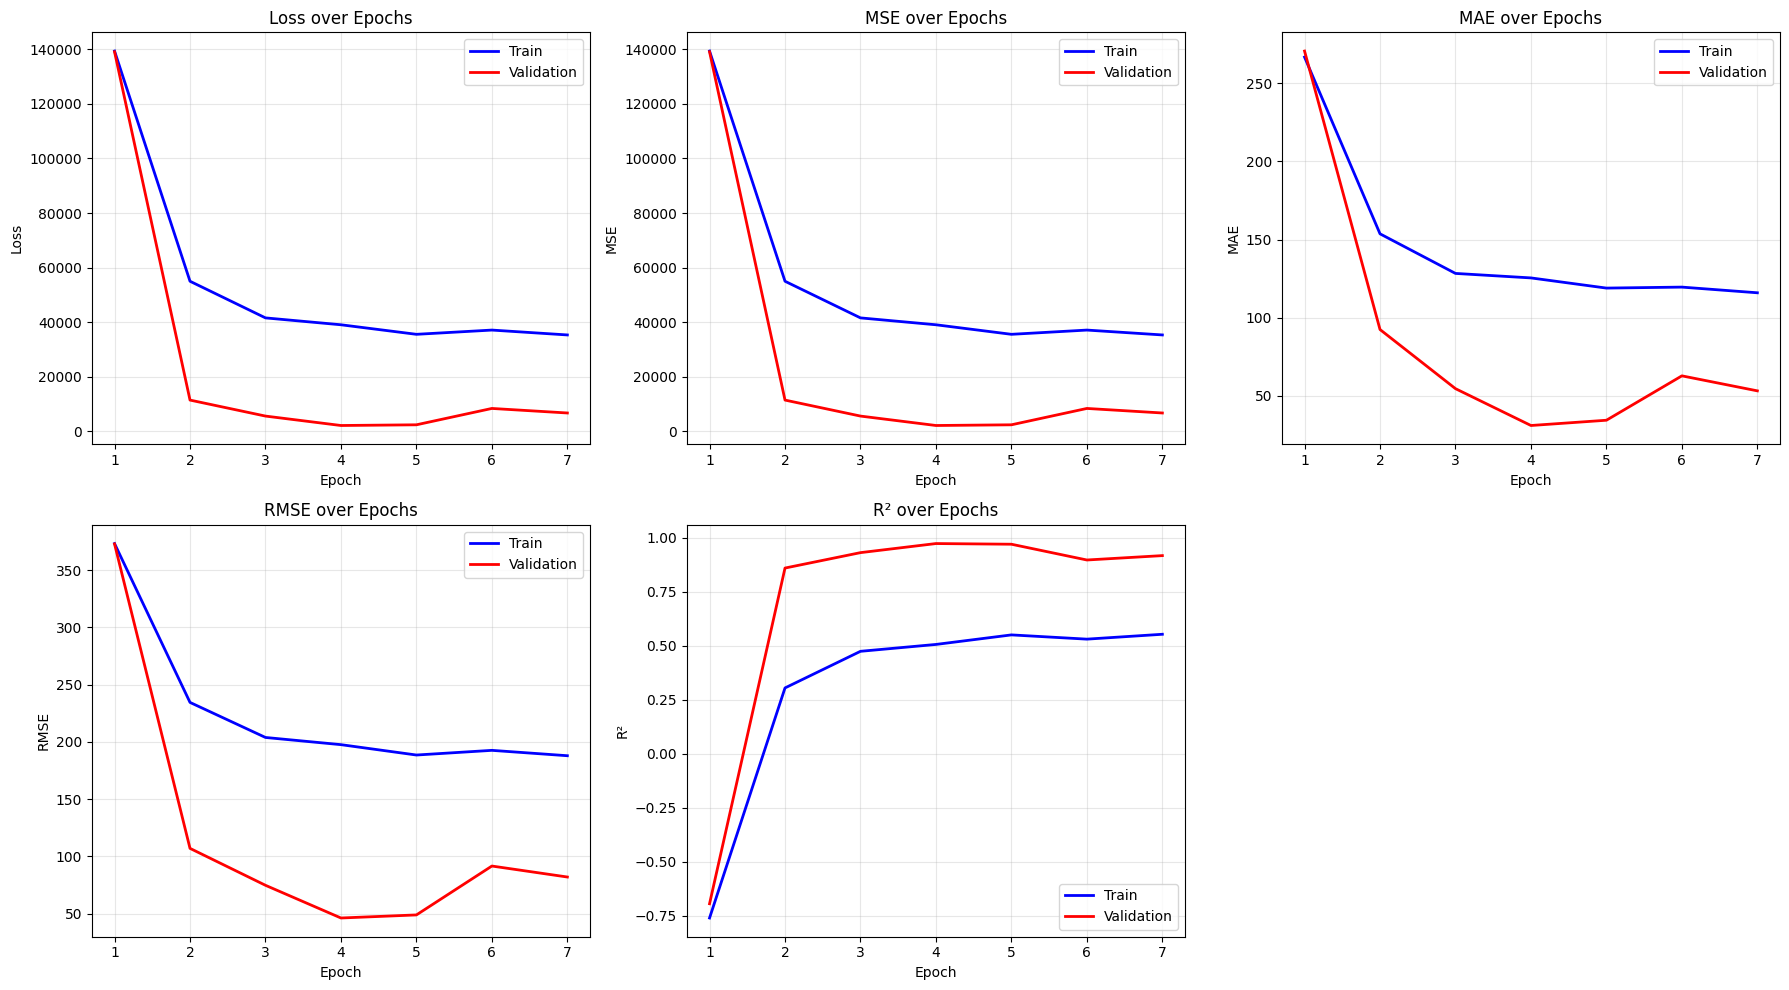


Všetky histórie trénovania uložené do c:\Users\pmuzslay\suns_z3\figures


In [33]:
for result in results:
    print(f"\nVykresľovanie histórie trénovania pre {result['config_name']}")
    fig = plot_training_history(
        result['history'],
        save_path=fig_dir / f"training_history_config_{result['config_idx']}.png"
    )
    plt.show()
    plt.close()

print(f"\nVšetky histórie trénovania uložené do {fig_dir}")

## 11. Súhrnné štatistiky

In [34]:
print("\n" + "="*80)
print("FINÁLNE ZHRNUTIE")
print("="*80)

print(f"\nNajlepšia konfigurácia: {best_result['config_name']}")
print(f"Počet parametrov: {best_result['num_parameters']:,}")
print("\nDetail konfigurácie:")
for key, value in best_result['config'].items():
    print(f"  {key}: {value}")

print("\nVýkon najlepšieho modelu:")
print("  Trénovacia množina:")
print(f"    MSE:  {best_result['train_metrics']['mse']:.4f}")
print(f"    MAE:  {best_result['train_metrics']['mae']:.4f}")
print(f"    RMSE: {best_result['train_metrics']['rmse']:.4f}")
print(f"    R²:   {best_result['train_metrics']['r2']:.4f}")
print("\n  Testovacia množina:")
print(f"    MSE:  {best_result['test_metrics']['mse']:.4f}")
print(f"    MAE:  {best_result['test_metrics']['mae']:.4f}")
print(f"    RMSE: {best_result['test_metrics']['rmse']:.4f}")
print(f"    R²:   {best_result['test_metrics']['r2']:.4f}")

print("\nVšetky výsledky a obrázky uložené do:")
print(f"  - Tabuľka výsledkov: {project_root / 'results_table.csv'}")
print(f"  - Obrázky: {fig_dir}")
print(f"  - Kontrolné body: {checkpoint_dir}")
print("="*80)



FINÁLNE ZHRNUTIE

Najlepšia konfigurácia: Konfigurácia 5: Širšia sieť
Počet parametrov: 389,401

Detail konfigurácie:
  name: Konfigurácia 5: Širšia sieť
  conv_channels: [24, 48, 96]
  fc_hidden: [48, 24]
  dropout: 0.65
  learning_rate: 0.0005
  weight_decay: 0.04
  batch_size: 128
  epochs: 8

Výkon najlepšieho modelu:
  Trénovacia množina:
    MSE:  2079.6860
    MAE:  30.6577
    RMSE: 45.6036
    R²:   0.9737

  Testovacia množina:
    MSE:  2063.7649
    MAE:  31.3709
    RMSE: 45.4287
    R²:   0.9744

Všetky výsledky a obrázky uložené do:
  - Tabuľka výsledkov: c:\Users\pmuzslay\suns_z3\results_table.csv
  - Obrázky: c:\Users\pmuzslay\suns_z3\figures
  - Kontrolné body: c:\Users\pmuzslay\suns_z3\checkpoints


## 12. Bonus: Vizualizácia konvolučných filtrov

Načítaný najlepší model: Konfigurácia 5: Širšia sieť
Počet konvolučných blokov: 3

Vizualizácia filtrov prvej konvolučnej vrstvy
Vrstva 0: 24 filtrov s tvarom torch.Size([3, 3, 3]) (zobrazených 24)
Filtre uložené do c:\Users\pmuzslay\suns_z3\figures\conv_filters_layer_0_config_5.png
Filtre uložené do c:\Users\pmuzslay\suns_z3\figures\conv_filters_layer_0_config_5.png


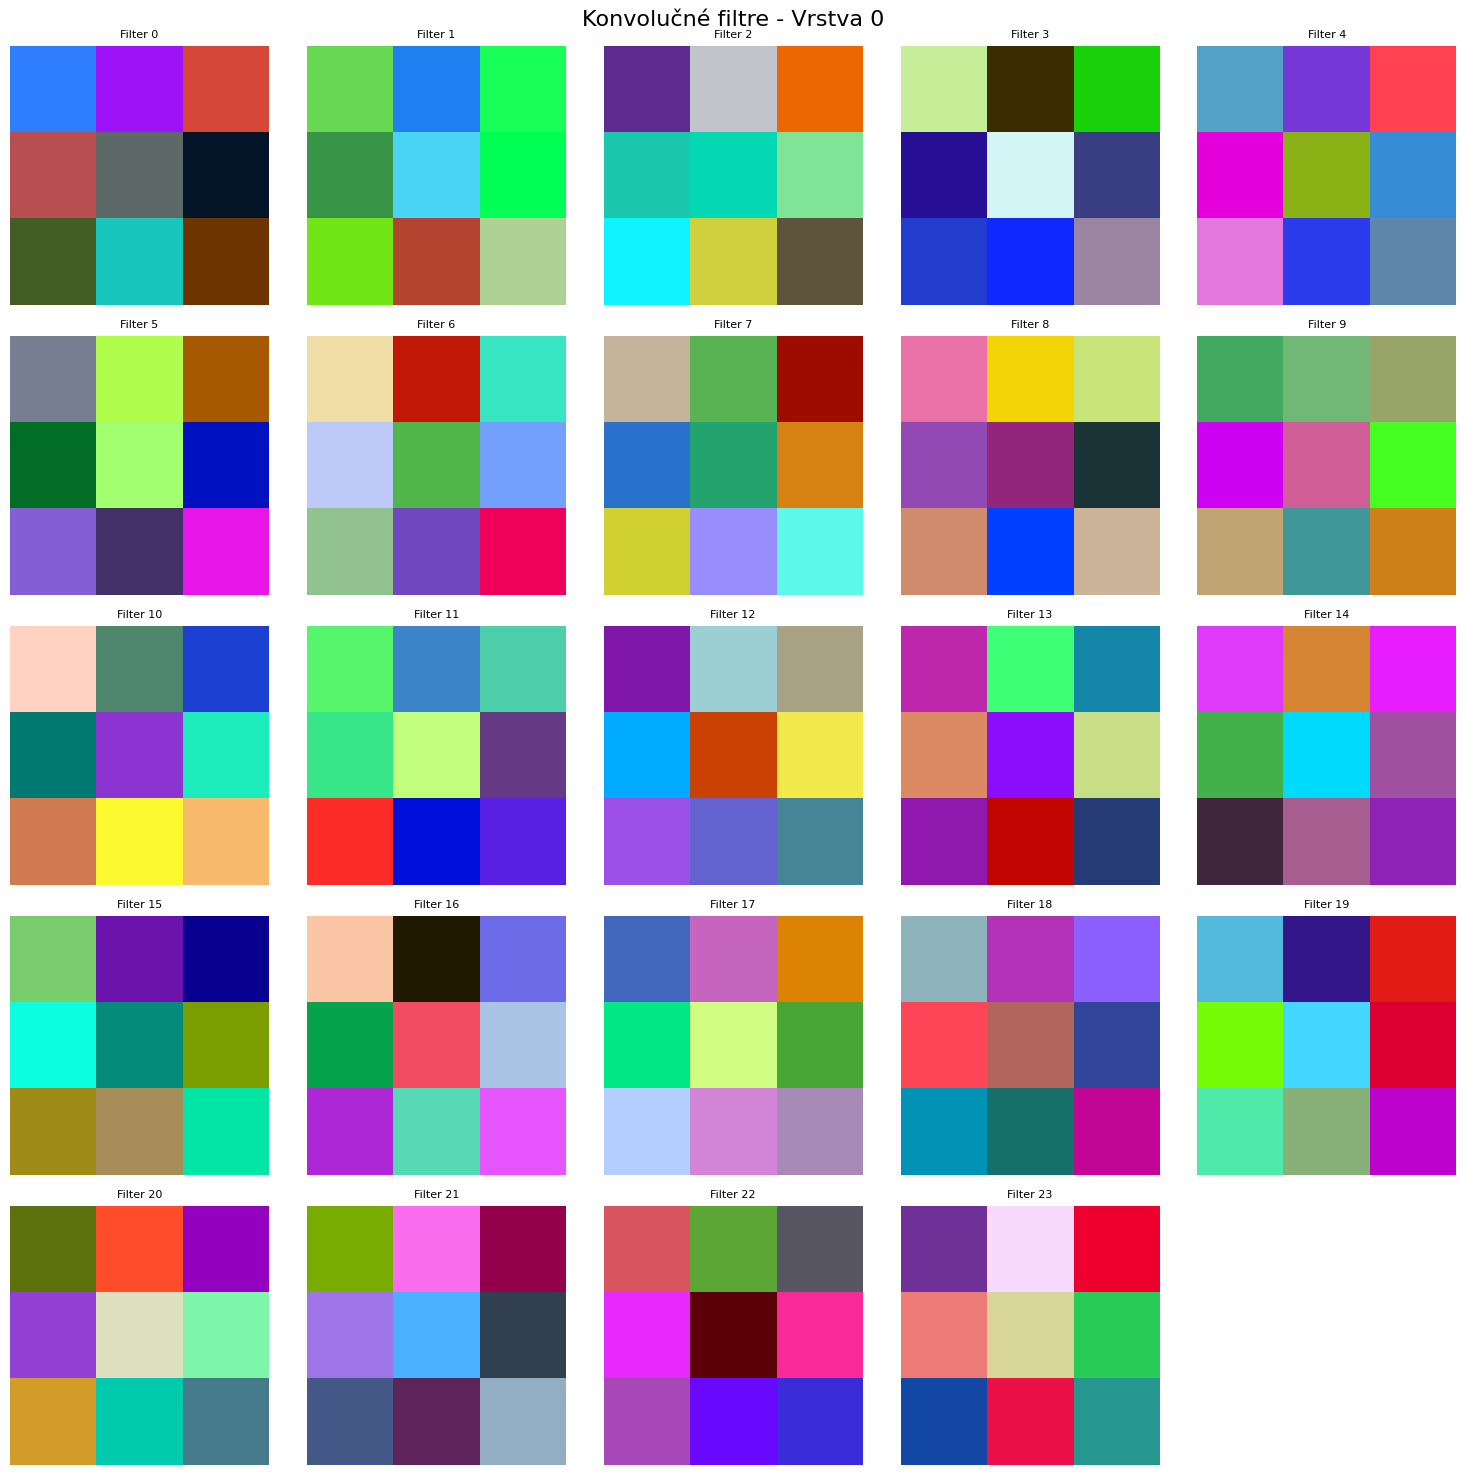


Vizualizácia filtrov druhej konvolučnej vrstvy
Vrstva 1: 48 filtrov s tvarom torch.Size([24, 3, 3]) (zobrazených 32)
Filtre uložené do c:\Users\pmuzslay\suns_z3\figures\conv_filters_layer_1_config_5.png
Filtre uložené do c:\Users\pmuzslay\suns_z3\figures\conv_filters_layer_1_config_5.png


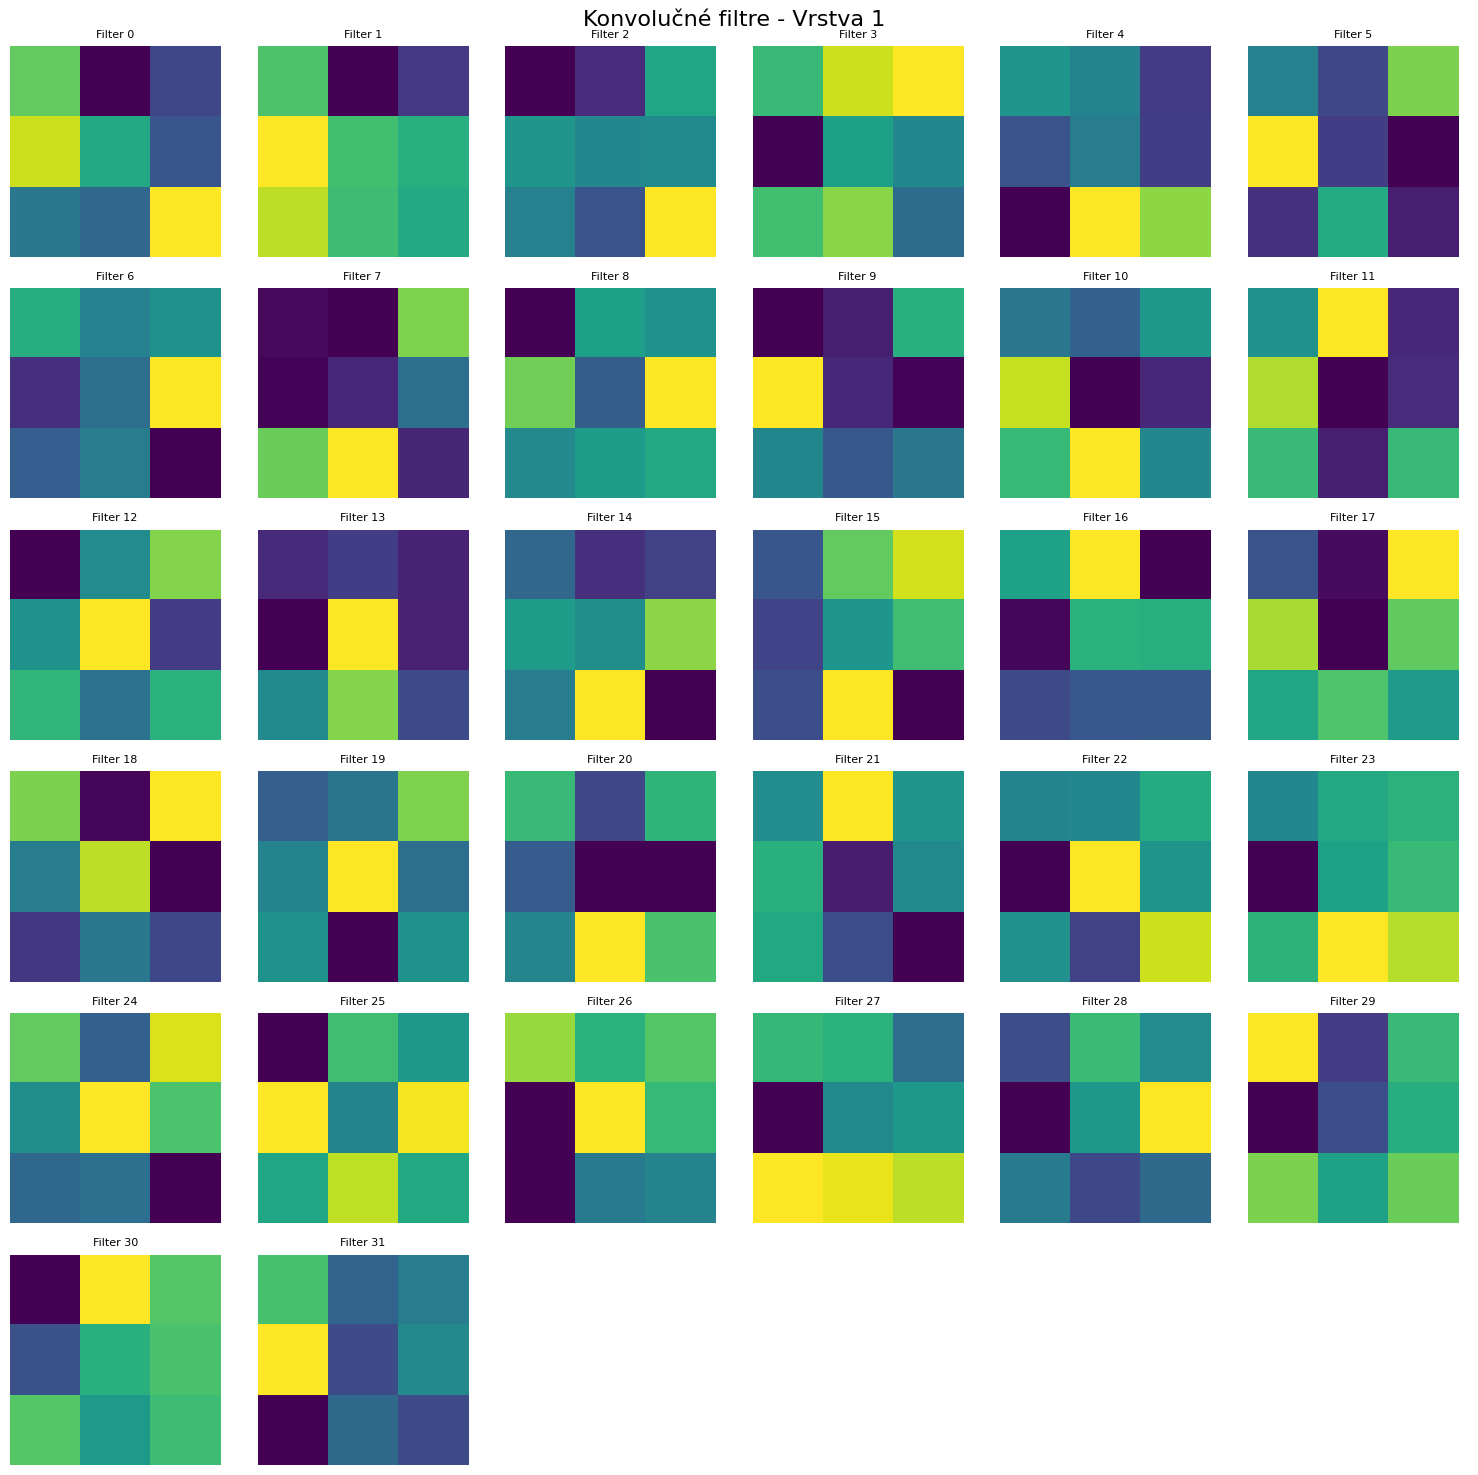

In [35]:
from utils.bonus import visualize_conv_filters

best_model = create_cnn_model(
    conv_channels=best_result['config']['conv_channels'],
    fc_hidden=best_result['config']['fc_hidden'],
    dropout_rate=best_result['config']['dropout'],
    device=device,
)

best_model_path = checkpoint_dir / f"config_{best_result['config_idx']}" / "best_model.pth"
optimizer_dummy, _ = create_optimizer_and_criterion(best_model, learning_rate=0.001)
load_checkpoint(best_model, optimizer_dummy, best_model_path, device)
best_model.eval()

print(f"Načítaný najlepší model: {best_result['config_name']}")
print(f"Počet konvolučných blokov: {len(best_model.conv_layers)}")

print("\n" + "="*60)
print("Vizualizácia filtrov prvej konvolučnej vrstvy")
print("="*60)
save_path = fig_dir / f"conv_filters_layer_0_config_{best_result['config_idx']}.png"
visualize_conv_filters(best_model, layer_idx=0, max_filters=32, save_path=save_path)
plt.show()

if len(best_model.conv_layers) > 1:
    print("\n" + "="*60)
    print("Vizualizácia filtrov druhej konvolučnej vrstvy")
    print("="*60)
    save_path = fig_dir / f"conv_filters_layer_1_config_{best_result['config_idx']}.png"
    visualize_conv_filters(best_model, layer_idx=1, max_filters=32, save_path=save_path)
    plt.show()


## 13. Bonus: Testovanie na vlastných obrázkoch oblohy

In [36]:
from utils.bonus import predict_custom_images

my_images_dir = project_root / "dataset" / "Solar_data" / "my_images"
my_images_dir.mkdir(parents=True, exist_ok=True)

print("="*80)
print("TESTOVANIE NA VLASTNÝCH OBRÁZKOCH OBLOHY")
print("="*80)
print(f"\nPriečinok s obrázkami: {my_images_dir}")

custom_results = predict_custom_images(best_model, my_images_dir, device)

if len(custom_results) >= 5:
    print(f"\nÚspešne spracovaných {len(custom_results)} vlastných obrázkov")
elif len(custom_results) > 0:
    print(f"\nNájdených len {len(custom_results)} obrázkov (minimum je 5)")
else:
    print("\nŽiadne obrázky neboli nájdené. Prosím pridajte vlastné fotografie oblohy do:")
    print(f"  {my_images_dir}")


TESTOVANIE NA VLASTNÝCH OBRÁZKOCH OBLOHY

Priečinok s obrázkami: c:\Users\pmuzslay\suns_z3\dataset\Solar_data\my_images
Nájdených 5 obrázkov v c:\Users\pmuzslay\suns_z3\dataset\Solar_data\my_images
  blumental_20251127_104827.jpg: 824.38 W/m²
  FEI_20251128_092755.jpg: 692.11 W/m²
  kuchajda_20251127_075407.jpg: 490.92 W/m²
  kuchajda_20251127_154347.jpg: 732.22 W/m²
  mlynska_dolina20251127_184021.jpg: 1.76 W/m²

Úspešne spracovaných 5 vlastných obrázkov
  blumental_20251127_104827.jpg: 824.38 W/m²
  FEI_20251128_092755.jpg: 692.11 W/m²
  kuchajda_20251127_075407.jpg: 490.92 W/m²
  kuchajda_20251127_154347.jpg: 732.22 W/m²
  mlynska_dolina20251127_184021.jpg: 1.76 W/m²

Úspešne spracovaných 5 vlastných obrázkov


### 14.1 Vizualizácia predikcií vlastných obrázkov


Vizualizácia vlastných obrázkov uložená do c:\Users\pmuzslay\suns_z3\figures\custom_images_predictions_config_5.png

Štatistiky predikcií:
  Priemerne žiarenie: 548.28 W/m²
  Min žiarenie:       1.76 W/m²
  Max žiarenie:       824.38 W/m²
  Štandardná odchýlka: 294.19 W/m²


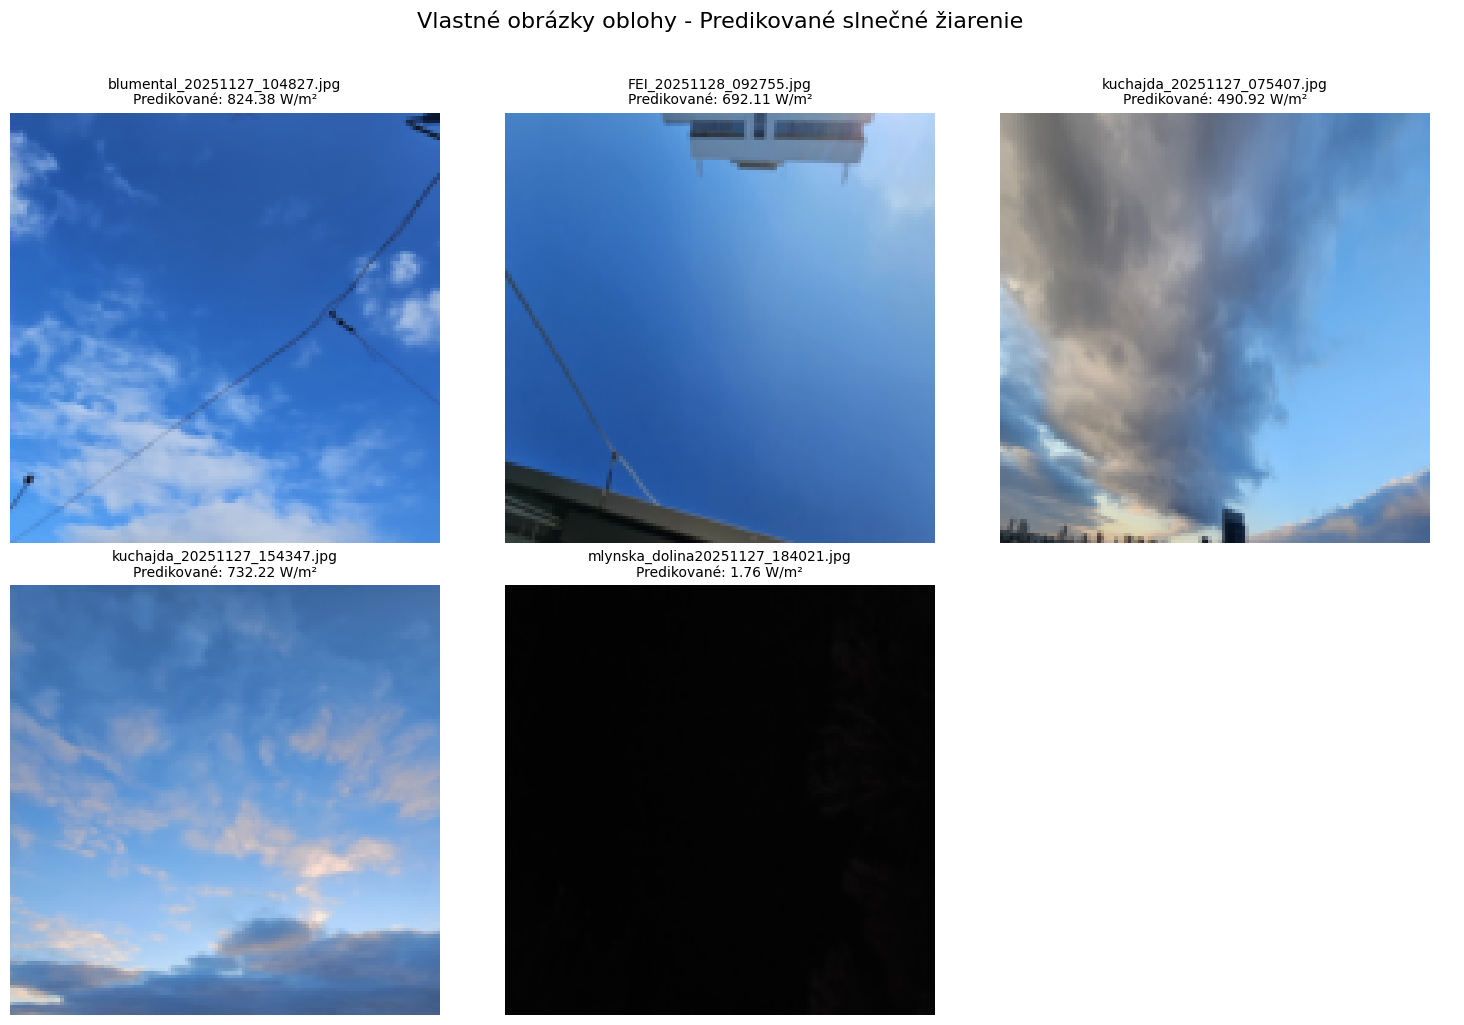

In [37]:
from utils.bonus import visualize_custom_predictions

if len(custom_results) > 0:
    save_path = fig_dir / f"custom_images_predictions_config_{best_result['config_idx']}.png"
    visualize_custom_predictions(custom_results, save_path=save_path)
    plt.show()
else:
    print("Žiadne vlastné obrázky na vizualizáciu. Pridajte obrázky do priečinka my_images a spustite túto bunku znovu.")


# BONUS: Predikcia žiarenia o 15 minút

In [38]:

import pandas as pd

def prepare_prediction_data_from_processed(df_polars, data_dir):
    """
    Pripraví dáta pre predikciu o 15 minút z Polars DataFrame.
    Páruje aktuálny obrázok s hodnotou žiarenia o 15 minút neskôr.
    """
    df = df_polars.to_pandas(use_pyarrow_extension_array=False)

    
    df['DateTime_parsed'] = pd.to_datetime(df['DateTime_clean'], format='%d/%m/%Y %H:%M:%S.%f', errors='coerce')
    
    df = df.sort_values(['Month', 'DateTime_parsed']).reset_index(drop=True)
    
    prediction_data = []
    
    for i in range(len(df) - 1):
        current_row = df.iloc[i]
        next_row = df.iloc[i + 1]
        
        if current_row['Month'] != next_row['Month']:
            continue
            
        if pd.isna(current_row['DateTime_parsed']) or pd.isna(next_row['DateTime_parsed']):
            continue
            
        time_diff = (next_row['DateTime_parsed'] - current_row['DateTime_parsed']).total_seconds() / 60
        
        if 10 <= time_diff <= 20:
            prediction_data.append({
                'PictureName': current_row['PictureName'],
                'Month': current_row['Month'],
                'CurrentIrradiance': current_row['Irradiance'],
                'FutureIrradiance': next_row['Irradiance'],
                'TimeDiff': time_diff
            })
    
    prediction_df = pd.DataFrame(prediction_data)
    return prediction_df

print("Príprava dát pre predikciu o 15 minút...")
pred_df = prepare_prediction_data_from_processed(train_df, data_dir)
print(f"Vytvorených párov z trénovacích dát: {len(pred_df)}")

pred_val = prepare_prediction_data_from_processed(val_df, data_dir)
pred_test = prepare_prediction_data_from_processed(test_df, data_dir)
print(f"Vytvorených párov z validačných dát: {len(pred_val)}")
print(f"Vytvorených párov z testovacích dát: {len(pred_test)}")

if len(pred_df) > 0:
    print(f"\nPriemerný časový rozdiel: {pred_df['TimeDiff'].mean():.1f} min")

Príprava dát pre predikciu o 15 minút...
Vytvorených párov z trénovacích dát: 1173
Vytvorených párov z validačných dát: 54
Vytvorených párov z testovacích dát: 40

Priemerný časový rozdiel: 15.0 min
Vytvorených párov z trénovacích dát: 1173
Vytvorených párov z validačných dát: 54
Vytvorených párov z testovacích dát: 40

Priemerný časový rozdiel: 15.0 min


In [39]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# Transformácie - rovnaké ako pri trénovaní
pred_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PredictionDataset(Dataset):
    """Dataset pre predikciu žiarenia o 15 minút."""
    
    def __init__(self, prediction_df, data_dir, transform=None):
        self.prediction_df = prediction_df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.prediction_df)
    
    def __getitem__(self, idx):
        row = self.prediction_df.iloc[idx]
        
        month_str = str(int(row['Month'])).zfill(2)
        image_path = self.data_dir / month_str / "original" / row['PictureName']
        
        try:
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
        except Exception as e:
            print(f"Chyba pri načítaní {image_path}: {e}")
            image = torch.zeros(3, 128, 128)
        
        target = torch.tensor(row['FutureIrradiance'], dtype=torch.float32)
        
        return image, target

if len(pred_df) > 0:
    pred_train_dataset = PredictionDataset(pred_df, data_dir, transform=pred_transform)
    pred_val_dataset = PredictionDataset(pred_val, data_dir, transform=pred_transform)
    pred_test_dataset = PredictionDataset(pred_test, data_dir, transform=pred_transform)
    
    batch_size = best_result['config']['batch_size']
    pred_train_loader = DataLoader(pred_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    pred_val_loader = DataLoader(pred_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    pred_test_loader = DataLoader(pred_test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"Trénovacia množina: {len(pred_train_dataset)}")
    print(f"Validačná množina: {len(pred_val_dataset)}")
    print(f"Testovacia množina: {len(pred_test_dataset)}")
else:
    print("Nedostatok dát pre predikciu o 15 minút!")

Trénovacia množina: 1173
Validačná množina: 54
Testovacia množina: 40


In [40]:


if len(pred_df) > 0:
    print("Trénovanie CNN pre predikciu žiarenia o 15 minút...")
    print("="*60)
    best_config = best_result['config']
    print(f"Konfigurácia: {best_config['name']}")
    
    pred_model = create_cnn_model(
        conv_channels=best_config['conv_channels'],
        fc_hidden=best_config['fc_hidden'],
        dropout_rate=best_config['dropout'],
        device=device,
    )
    
    pred_optimizer, pred_criterion = create_optimizer_and_criterion(
        pred_model,
        learning_rate=best_config['learning_rate'],
        weight_decay=best_config['weight_decay'],
        optimizer_type="adamw",
    )
    
    pred_history = train_model(
        model=pred_model,
        train_loader=pred_train_loader,
        val_loader=pred_val_loader,
        criterion=pred_criterion,
        optimizer=pred_optimizer,
        epochs=best_config['epochs'],
        device=device,
        checkpoint_dir=checkpoint_dir / "prediction_15min",
        early_stopping_patience=3,
        verbose=True,
    )
    
    print("\nTrénovanie dokončené!")
else:
    print("Preskakujem trénovanie - nedostatok dát")

Trénovanie CNN pre predikciu žiarenia o 15 minút...
Konfigurácia: Konfigurácia 5: Širšia sieť


Epoch 1: 100%|██████████| 10/10 [00:21<00:00,  2.19s/it, loss=1.62e+5]




Epoch 1/8:
  Train - Loss: 155690.0549, MSE: 155690.0469, MAE: 289.0075, RMSE: 394.5758, R2: -1.1386
  Val   - Loss: 163264.8125, MSE: 163264.8281, MAE: 288.6185, RMSE: 404.0604, R2: -1.0416


Epoch 2: 100%|██████████| 10/10 [00:19<00:00,  1.99s/it, loss=1.89e+5]




Epoch 2/8:
  Train - Loss: 149772.5927, MSE: 149772.6094, MAE: 282.0608, RMSE: 387.0047, R2: -1.0573
  Val   - Loss: 163165.0781, MSE: 163165.0938, MAE: 288.5573, RMSE: 403.9370, R2: -1.0404


...


Epoch 6/8:
  Train - Loss: 69615.6241, MSE: 69615.6250, MAE: 178.5771, RMSE: 263.8477, R2: 0.0437
  Val   - Loss: 44547.0820, MSE: 44547.0781, MAE: 139.7030, RMSE: 211.0618, R2: 0.4429


Epoch 7: 100%|██████████| 10/10 [00:20<00:00,  2.00s/it, loss=6.69e+4]




Epoch 7/8:
  Train - Loss: 57700.4329, MSE: 57700.4336, MAE: 159.9179, RMSE: 240.2092, R2: 0.2074
  Val   - Loss: 20105.9727, MSE: 20105.9746, MAE: 98.8654, RMSE: 141.7955, R2: 0.7486


Epoch 8: 100%|██████████| 10/10 [00:19<00:00,  1.97s/it, loss=5.18e+4]




Epoch 8/8:
  Train - Loss: 58595.3773, MSE: 58595.3750, MAE: 158.9066, RMSE: 242.0648, R2: 0.1951
  Val   - Loss: 30676.6074, MSE: 30676.6074, MAE: 149.6836, RMSE: 175.1474, R2: 0.6164

Trénovanie dokončené!


In [41]:
if len(pred_df) > 0:
    print("Evaluácia modelu pre predikciu o 15 minút")
    print("="*60)
    
    pred_metrics = evaluate_model(pred_model, pred_test_loader, pred_criterion, device)
    
    print("\nVýsledky predikcie o 15 minút:")
    print(f"  MSE:  {pred_metrics['mse']:.4f}")
    print(f"  MAE:  {pred_metrics['mae']:.4f}")
    print(f"  RMSE: {pred_metrics['rmse']:.4f}")
    print(f"  R²:   {pred_metrics['r2']:.4f}")
    
    print("\nPorovnanie:")
    print(f"  Odhad (aktuálne žiarenie):    R²={best_result['test_metrics']['r2']:.4f}, RMSE={best_result['test_metrics']['rmse']:.4f}")
    print(f"  Predikcia (o 15 min):         R²={pred_metrics['r2']:.4f}, RMSE={pred_metrics['rmse']:.4f}")
else:
    print("Preskakujem evaluáciu - model nebol natrénovaný")

Evaluácia modelu pre predikciu o 15 minút

Výsledky predikcie o 15 minút:
  MSE:  32542.7246
  MAE:  159.8253
  RMSE: 180.3960
  R²:   0.5901

Porovnanie:
  Odhad (aktuálne žiarenie):    R²=0.9744, RMSE=45.4287
  Predikcia (o 15 min):         R²=0.5901, RMSE=180.3960

Výsledky predikcie o 15 minút:
  MSE:  32542.7246
  MAE:  159.8253
  RMSE: 180.3960
  R²:   0.5901

Porovnanie:
  Odhad (aktuálne žiarenie):    R²=0.9744, RMSE=45.4287
  Predikcia (o 15 min):         R²=0.5901, RMSE=180.3960


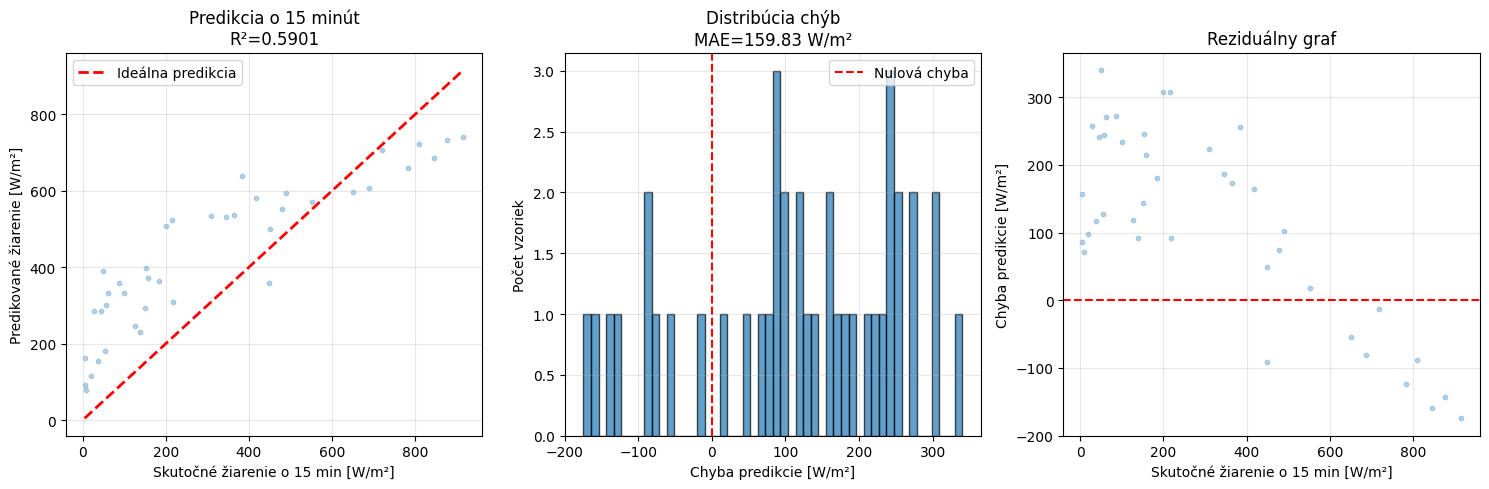


Graf uložený: c:\Users\pmuzslay\suns_z3\figures\bonus_prediction_15min.png


In [42]:
if len(pred_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    all_preds = pred_metrics['predictions']
    all_targets = pred_metrics['targets']
    
    # 1. Predikcie vs skutočné hodnoty
    ax1 = axes[0]
    ax1.scatter(all_targets, all_preds, alpha=0.3, s=10)
    min_val = min(all_targets.min(), all_preds.min())
    max_val = max(all_targets.max(), all_preds.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideálna predikcia')
    ax1.set_xlabel('Skutočné žiarenie o 15 min [W/m²]')
    ax1.set_ylabel('Predikované žiarenie [W/m²]')
    ax1.set_title(f'Predikcia o 15 minút\nR²={pred_metrics["r2"]:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Distribúcia chýb
    ax2 = axes[1]
    errors = all_preds - all_targets
    ax2.hist(errors, bins=50, edgecolor='black', alpha=0.7)
    ax2.axvline(0, color='r', linestyle='--', label='Nulová chyba')
    ax2.set_xlabel('Chyba predikcie [W/m²]')
    ax2.set_ylabel('Počet vzoriek')
    ax2.set_title(f'Distribúcia chýb\nMAE={pred_metrics["mae"]:.2f} W/m²')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Residuals vs skutočné
    ax3 = axes[2]
    ax3.scatter(all_targets, errors, alpha=0.3, s=10)
    ax3.axhline(0, color='r', linestyle='--')
    ax3.set_xlabel('Skutočné žiarenie o 15 min [W/m²]')
    ax3.set_ylabel('Chyba predikcie [W/m²]')
    ax3.set_title('Reziduálny graf')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_prediction_15min.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nGraf uložený: {fig_dir / 'bonus_prediction_15min.png'}")
else:
    print("Preskakujem vizualizáciu - model nebol natrénovaný")